# Машинное обучение, ФКН ВШЭ

## Практическое задание 2. Exploratory Data Analysis и линейная регрессия

### Общая информация
Дата выдачи: 25.09.2022

Мягкий дедлайн: 23:59MSK 10.10.2022

Жесткий дедлайн: 23:59MSK 18.10.2022

### О задании
В этом задании мы попытаемся научиться анализировать данные и выделять из них полезные признаки. Мы также научимся пользоваться `seaborn` и `sklearn`, а заодно привыкнем к основным понятиям машинного обучения.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Проверяющий имеет право снизить оценку за неэффективную реализацию или неопрятные графики.

**Обратите внимание**, что в каждом разделе домашнего задания есть оцениваниемые задачи и есть вопросы. Вопросы дополняют задачи и направлены на то, чтобы проинтерпретировать или обосновать происходящее. Код без интерпретации не имеет смысла, поэтому отвечать на вопросы обязательно — за отсутствие ответов мы будем снижать баллы за задачи. Если вы ответите на вопросы, но не напишете корректный код к соответствующим оцениваемым задачам, то баллы за такое выставлены не будут.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате homework-practice-02-linregr-Username.ipynb, где Username — ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

Оценка: xx.

В этом ноутбуке используется библиотека `folium` для визуализации карт. Она работает в google colab!

In [1]:
#pip install folium

In [1]:
import folium

m = folium.Map(location=(55.7522200, 37.6155600), zoom_start=10)

m

Если вы всё сделали правильно, то выше должна открыться карта Москвы.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set(style="darkgrid")

## Часть 0. Подготовка (1 балл)

**Задание 1 (1 балл)**. Мы будем работать с данными из соревнования [New York City Taxi Trip Duration](https://www.kaggle.com/c/nyc-taxi-trip-duration/overview), в котором нужно было предсказать длительность поездки на такси. Скачайте обучающую выборку из этого соревнования и загрузите ее:

In [3]:
df = pd.read_csv("train.csv")

print(df.head())
print(df.info())

          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564         -73.999481   
2                1        -73.979027        40.763939         -74.005333   
3                1        -74.010040        40.719971         -74.012268   
4                1        -73.973053        40.793209         -73.972923   

   dropoff_latitude store_and_fwd_flag  trip_duration  
0         40.765602                  N            455  
1         40.731

Обратите внимание на колонки `pickup_datetime` и `dropoff_datetime`. `dropoff_datetime` был добавлена организаторами только в обучающую выборку, то есть использовать эту колонку нельзя, давайте удалим ее. В `pickup_datetime` записаны дата и время начала поездки. Чтобы с ней было удобно работать, давайте преобразуем даты в `datetime`-объекты

In [4]:
df = df.drop('dropoff_datetime', axis=1)
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

print(df.head())

          id  vendor_id     pickup_datetime  passenger_count  \
0  id2875421          2 2016-03-14 17:24:55                1   
1  id2377394          1 2016-06-12 00:43:35                1   
2  id3858529          2 2016-01-19 11:35:24                1   
3  id3504673          2 2016-04-06 19:32:31                1   
4  id2181028          2 2016-03-26 13:30:55                1   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.982155        40.767937         -73.964630         40.765602   
1        -73.980415        40.738564         -73.999481         40.731152   
2        -73.979027        40.763939         -74.005333         40.710087   
3        -74.010040        40.719971         -74.012268         40.706718   
4        -73.973053        40.793209         -73.972923         40.782520   

  store_and_fwd_flag  trip_duration  
0                  N            455  
1                  N            663  
2                  N           2124  


В колонке `trip_duration` записано целевое значение, которое мы хотим предсказывать. Давайте посмотрим на распределение таргета в обучающей выборке. Для этого нарисуйте его гистограмму:

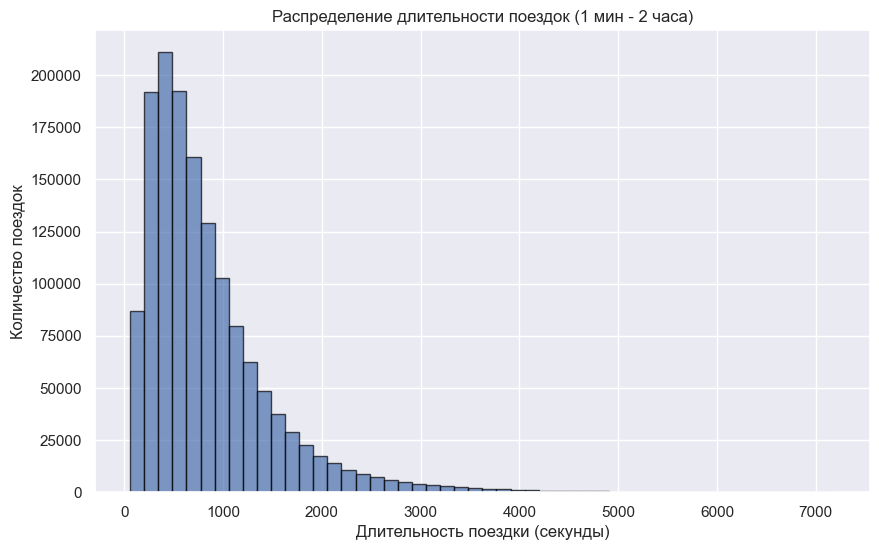

Отфильтровано 10848 поездок (0.7% данных)


In [5]:
import matplotlib.pyplot as plt
import numpy as np

df_filtered = df[(df['trip_duration'] >= 60) & (df['trip_duration'] <= 7200)]

plt.figure(figsize=(10, 6))
plt.hist(df_filtered['trip_duration'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Длительность поездки (секунды)')
plt.ylabel('Количество поездок')
plt.title('Распределение длительности поездок (1 мин - 2 часа)')
plt.show()

print(f"Отфильтровано {len(df) - len(df_filtered)} поездок ({(1 - len(df_filtered)/len(df))*100:.1f}% данных)")

**Вопрос**: Что можно сказать о целевой переменной по гистограмме её значений?

Большинство поездок имеют небольшую длительность, распределение не является Гауссовским, имеются выбросы - длинный хвост

В соревновании в качестве метрики качества использовалось RMSLE:
$$\text{RMSLE}(X, y, a) = \sqrt{\frac{1}{\ell}\sum_{i=1}^{\ell} \big(\log{(y_i + 1)} - \log{(a(x_i) + 1)}\big)^2}$$

**Вопрос**: Как вы думаете, почему авторы соревнования выбрали именно RMSLE, а не RMSE?

RMSLE утойчив к выбросам и работает с широким диапазоном значений

На семинаре мы рассматривали несколько моделей линейной регрессии в `sklearn`, но каждая из них оптимизировала среднеквадратичную ошибку (MSE), а не RMSLE. Давайте проделаем следующий трюк: будем предсказывать не целевую переменную, а ее *логарифм*. Обозначим $\hat{y}_i = \log{(y_i + 1)}$ — модифицированный таргет, а $\hat{a}(x_i)$ — предсказание модели, которая обучалась на $\hat{y}_i$, то есть логарифм таргета. Чтобы предсказать исходное значение, мы можем просто взять экспоненту от нашего предсказания: $a(x_i) = \exp(\hat{a}(x_i)) - 1$.

**Вопрос**: Покажите, что оптимизация RMSLE для модели $a$ эквивалентна оптимизации MSE для модели $\hat{a}$.

**Доказательство**: ŷ_i = log(y_i + 1) - логарифмический таргет
â(x_i) - предсказание модели, обученной на ŷ_i,
RMSLE = √(1/n * Σ(log(y_i + 1) - log(ŷ_i + 1))²),
Если предсказывать log(y_i + 1), то:
MSE = 1/n * Σ(ŷ_i - log(y_i + 1))²,
ЧТД

Итак, мы смогли свести задачу оптимизации RMSLE к задаче оптимизации MSE, которую мы умеем решать! Кроме того, у логарифмирования таргета есть еще одно полезное свойство. Чтобы его увидеть, добавьте к нашей выборке колонку `log_trip_duration` (воспользуйтесь `np.log1p`) и нарисуйте гистограмму модифицированного таргета по обучающей выборке. Удалите колонку со старым таргетом.

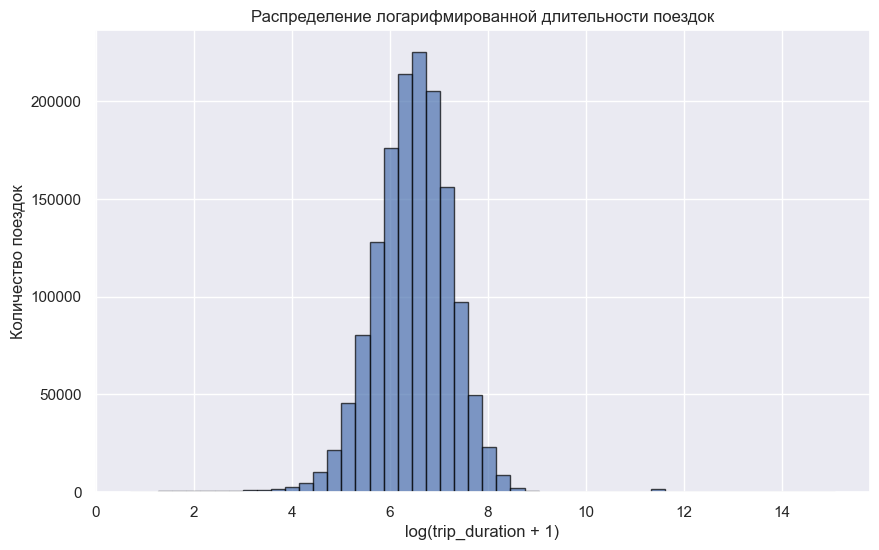

In [6]:
df['log_trip_duration'] = np.log1p(df['trip_duration'])

plt.figure(figsize=(10, 6))
plt.hist(df['log_trip_duration'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('log(trip_duration + 1)')
plt.ylabel('Количество поездок')
plt.title('Распределение логарифмированной длительности поездок')
plt.show()

df = df.drop('trip_duration', axis=1)

Чтобы иметь некоторую точку отсчета, давайте посчитаем значение метрики при наилучшем константном предсказании:

In [7]:
from sklearn.metrics import mean_squared_log_error
import numpy as np

const_pred = np.median(df['log_trip_duration'])

y_true = np.expm1(df['log_trip_duration'])
y_pred_const = np.full(len(y_true), np.expm1(const_pred))

rmsle_const = np.sqrt(mean_squared_log_error(y_true, y_pred_const))
print(f"RMSLE константного предсказания: {rmsle_const:.4f}")

RMSLE константного предсказания: 0.7963


## Часть 1. Изучаем `pickup_datetime` (2 балла)

**Задание 2 (0.25 баллов)**. Для начала давайте посмотрим, сколько всего было поездок в каждый из дней. Постройте график зависимости количества поездок от дня в году (например, можно воспользоваться `sns.countplot`):

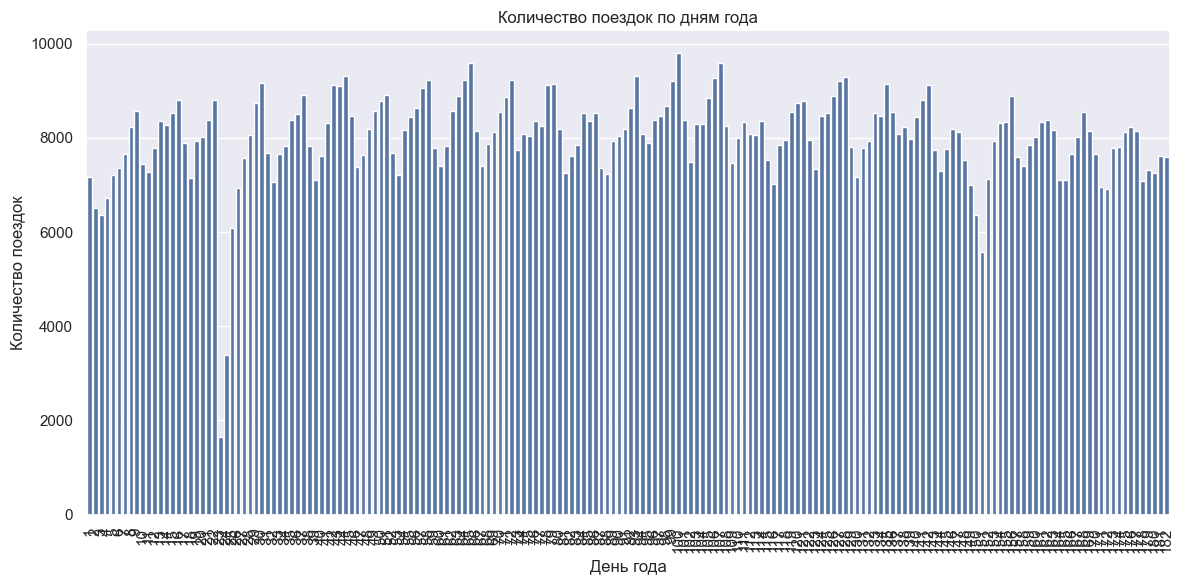

In [8]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x=df['pickup_datetime'].dt.dayofyear)
plt.xlabel('День года')
plt.ylabel('Количество поездок')
plt.title('Количество поездок по дням года')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Вопрос**: Вы, вероятно, заметили, что на графике есть 2 периода с аномально маленькими количествами поездок. Вычислите, в какие даты происходили эти скачки вниз и найдите информацию о том, что происходило в эти дни в Нью-Йорке.

Нарисуйте графики зависимости количества поездок от дня недели и от часов в сутках (воспользуйтесь `sns.relplot`):

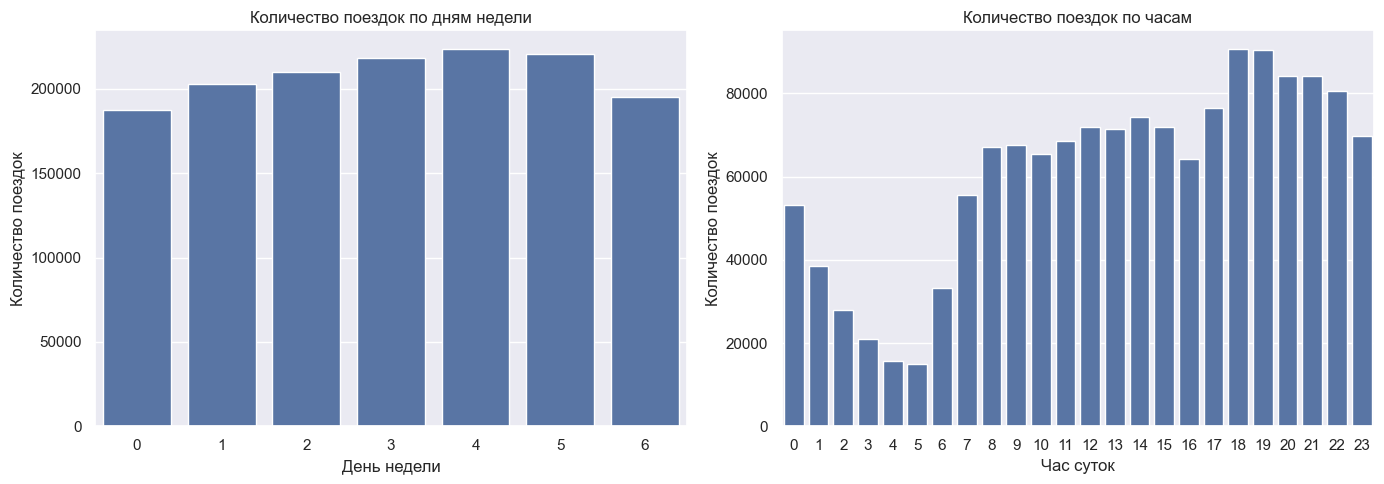

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x=df['pickup_datetime'].dt.dayofweek, ax=axes[0])
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Количество поездок')
axes[0].set_title('Количество поездок по дням недели')

sns.countplot(data=df, x=df['pickup_datetime'].dt.hour, ax=axes[1])
axes[1].set_xlabel('Час суток')
axes[1].set_ylabel('Количество поездок')
axes[1].set_title('Количество поездок по часам')

plt.tight_layout()
plt.show()

**Задание 3 (0.5 баллов)**. Нарисуйте на одном графике зависимости количества поездок от часа в сутках для разных месяцев (разные кривые, соответствующие разным месяцам, окрашивайте в разные цвета, воспользуйтесь `hue` в `sns.relplot`). Аналогично нарисуйте зависимости количества поездок от часа в сутках для разных дней недели.

In [10]:
print('gdgsgsdg')

gdgsgsdg


**Вопрос**: Какие выводы можно сделать, основываясь на графиках выше? Выделяются ли какие-нибудь дни недели? Месяца? Время суток? С чем это связано?

**Задание 4 (0.5 баллов)**. Разбейте выборку на обучающую и тестовую в отношении 7:3. По обучающей выборке нарисуйте график зависимости среднего логарифма времени поездки от дня недели. Затем сделайте то же самое, но для часа в сутках и дня в году.

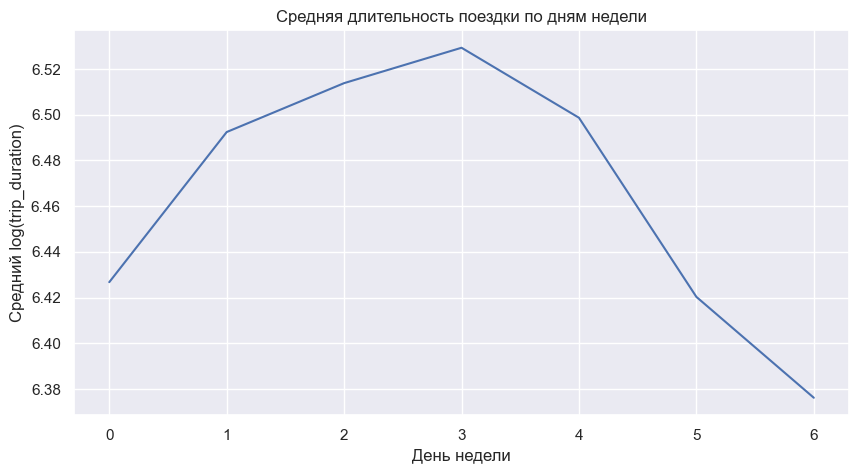

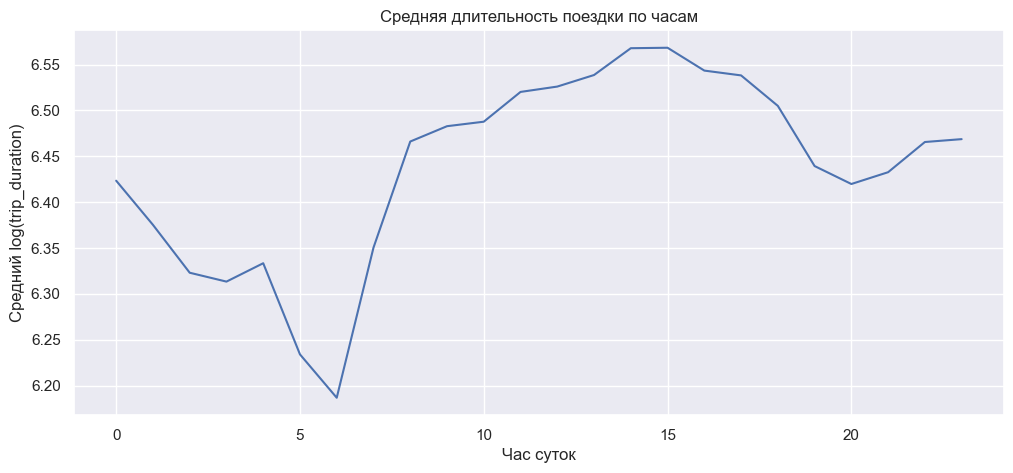

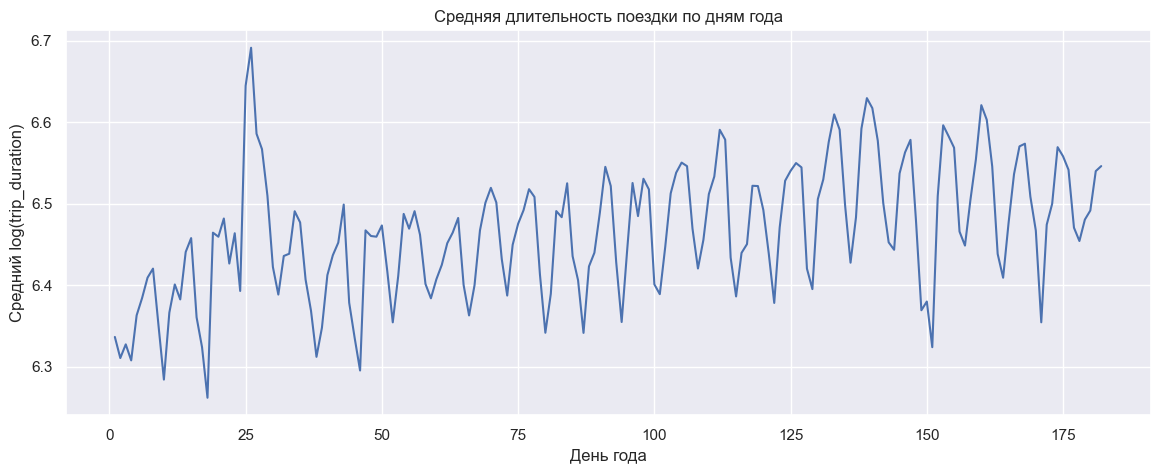

In [11]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

plt.figure(figsize=(10, 5))
train_df['dayofweek'] = train_df['pickup_datetime'].dt.dayofweek
train_df.groupby('dayofweek')['log_trip_duration'].mean().plot(kind='line')
plt.xlabel('День недели')
plt.ylabel('Средний log(trip_duration)')
plt.title('Средняя длительность поездки по дням недели')
plt.show()

plt.figure(figsize=(12, 5))
train_df['hour'] = train_df['pickup_datetime'].dt.hour
train_df.groupby('hour')['log_trip_duration'].mean().plot(kind='line')
plt.xlabel('Час суток')
plt.ylabel('Средний log(trip_duration)')
plt.title('Средняя длительность поездки по часам')
plt.show()

plt.figure(figsize=(14, 5))
train_df['dayofyear'] = train_df['pickup_datetime'].dt.dayofyear
train_df.groupby('dayofyear')['log_trip_duration'].mean().plot(kind='line')
plt.xlabel('День года')
plt.ylabel('Средний log(trip_duration)')
plt.title('Средняя длительность поездки по дням года')
plt.show()

**Вопрос**: Похожи ли графики зависимости таргета от дня недели и от часа в сутках на аналогичные графики для количества поездок? Почему? Что происходит со средним таргетом в те два аномальных периода, что мы видели выше? Почему так происходит? Наблюдаете ли вы какой-нибудь тренд на графике зависимости `log_trip_duration` от номера дня в году?

Добавьте следующие признаки на основе `pickup_datetime`:
1. День недели
2. Месяц
3. Час
4. Является ли период аномальным (два бинарных признака, соответствующие двум аномальным периодам)
5. Номер дня в году

In [12]:
df['dayofweek'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month
df['hour'] = df['pickup_datetime'].dt.hour
df['dayofyear'] = df['pickup_datetime'].dt.dayofyear

df['is_new_year'] = ((df['pickup_datetime'].dt.month == 1) & 
                     (df['pickup_datetime'].dt.day <= 2)).astype(int)
df['is_anomaly2'] = 0 

Итак, мы уже создали некоторое количество признаков.

**Вопрос**: Какие из признаков стоит рассматривать как категориальные, а какие - как численные? Почему?

**Задание 5 (0.75 баллов)**. Обучите `Ridge`-регрессию с параметрами по умолчанию, закодировав все категориальные признаки с помощью `OneHotEncoder`. Численные признаки отмасштабируйте с помощью `StandardScaler`. Используйте только признаки, которые мы выделили в этой части задания.

In [13]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_features = ['dayofweek', 'month']
numerical_features = ['hour', 'dayofyear', 'is_new_year', 'is_anomaly2']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

X = df[categorical_features + numerical_features]
y = df['log_trip_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ridge_pipeline.fit(X_train, y_train)

y_pred = ridge_pipeline.predict(X_test)

rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_test), np.expm1(y_pred)))
print(f"RMSLE Ridge регрессии: {rmsle:.4f}")

RMSLE Ridge регрессии: 0.7919


## Часть 2. Изучаем координаты (3 балла)
Мы уже очень хорошо изучили данные о времени начала поездки, давайте теперь посмотрим на информацию о координатах начала и конца поездки. Мы подготовили для вас функцию, которая на карте рисует точки начала или конца поездки. Примеры ее вызова вы найдете ниже. Обратите внимание, что в эту функцию мы передаем лишь небольшой кусочек данных, посколько иначе функция будет работать очень долго

In [14]:
def show_circles_on_map(data, latitude_column, longitude_column, color):
    """
    The function draws map with circles on it.
    The center of the map is the mean of coordinates passed in data.
    
    data: DataFrame that contains columns latitude_column and longitude_column
    latitude_column: string, the name of column for latitude coordinates
    longitude_column: string, the name of column for longitude coordinates
    color: string, the color of circles to be drawn
    """

    location = (data[latitude_column].mean(), data[longitude_column].mean())
    m = folium.Map(location=location)

    for _, row in data.iterrows():
        folium.Circle(
            radius=100,
            location=(row[latitude_column], row[longitude_column]),
            color=color,
            fill_color=color,
            fill=True
        ).add_to(m)

    return m

In [15]:
show_circles_on_map(df.sample(1000), "pickup_latitude", "pickup_longitude", "blue")

In [16]:
show_circles_on_map(df.sample(1000), "dropoff_latitude", "dropoff_longitude", "red")

**Вопрос**: Какие две точки выделяются на карте?

**Задание 6 (0.75 балл)**. Как мы все прекрасно помним, $t = s / v_{\text{ср}}$, поэтому очевидно, что самым сильным признаком будет расстояние, которое необходимо проехать. Мы не можем посчитать точное расстояние, которое необходимо преодолеть такси, но мы можем его оценить, посчитав кратчайшее расстояние между точками начала и конца поездки. Чтобы корректно посчитать расстояние между двумя точками на Земле, можно использовать функцию `haversine`. Также можно воспользоваться кодом с первого семинара. Посчитайте кратчайшее расстояние для объектов и запишите его в колонку `haversine`:

In [17]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

df['haversine'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                            df['dropoff_latitude'], df['dropoff_longitude'])

Так как мы предсказываем логарифм времени поездки и хотим, чтобы наши признаки были линейно зависимы с этой целевой переменной, нам нужно логарифмировать расстояние: $\log t = \log s - \log{v_{\text{ср}}}$. Запишите логарифм `haversine` в отдельную колонку:

In [18]:
df['log_haversine'] = np.log1p(df['haversine'])

Убедимся, что логарифм расстояния лучше коррелирует с нашим таргетом, чем просто расстояние:

In [19]:
print(f"Корреляция haversine с log_trip_duration: {df['haversine'].corr(df['log_trip_duration']):.4f}")
print(f"Корреляция log_haversine с log_trip_duration: {df['log_haversine'].corr(df['log_trip_duration']):.4f}")

Корреляция haversine с log_trip_duration: 0.5736
Корреляция log_haversine с log_trip_duration: 0.7499


**Задание 7 (0.75 балла)**. Давайте изучим среднюю скорость движения такси. Посчитайте среднюю скорость для каждого объекта обучающей выборки, разделив `haversine` на `trip_duration`, и нарисуйте гистограмму ее распределения

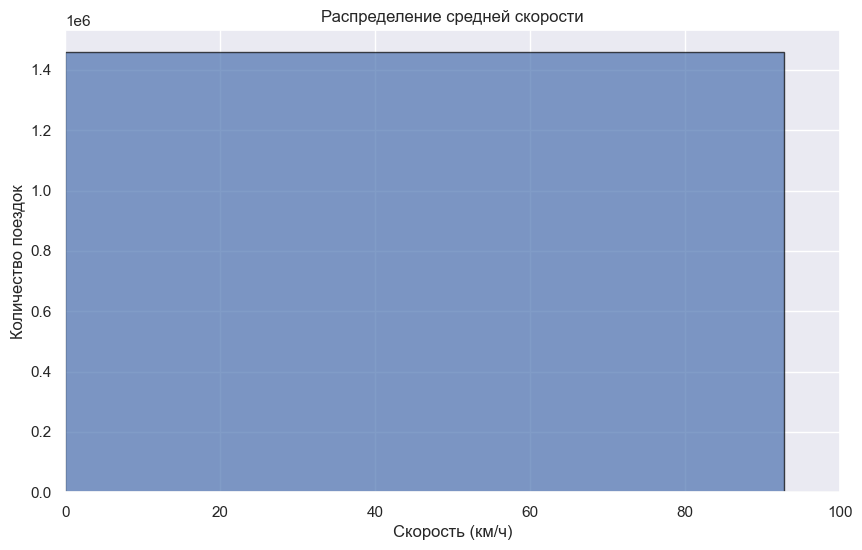

In [20]:
df['speed'] = df['haversine'] / (df['log_trip_duration'].apply(np.expm1) / 3600)

plt.figure(figsize=(10, 6))
plt.hist(df['speed'], bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Скорость (км/ч)')
plt.ylabel('Количество поездок')
plt.title('Распределение средней скорости')
plt.xlim(0, 100)
plt.show()

Как можно видеть по гистограмме, для некоторых объектов у нас получились очень больше значения скоростей. Нарисуйте гистограмму по объектам, для которых значение скорости получилось разумным (например, можно не включать рассмотрение объекты, где скорость больше некоторой квантили):

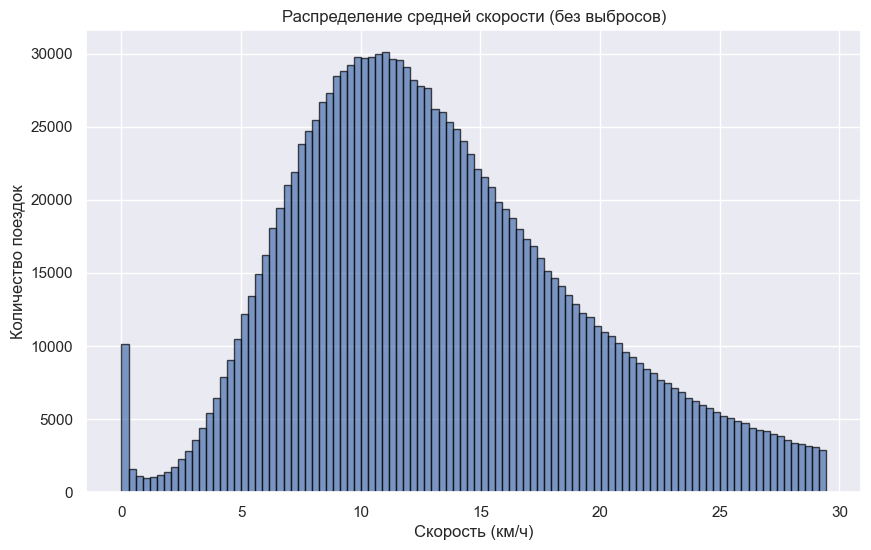

In [21]:
reasonable_speed = df[df['speed'] < df['speed'].quantile(0.95)]

plt.figure(figsize=(10, 6))
plt.hist(reasonable_speed['speed'], bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Скорость (км/ч)')
plt.ylabel('Количество поездок')
plt.title('Распределение средней скорости (без выбросов)')
plt.show()

Для каждой пары (день недели, час суток) посчитайте медиану скоростей. Нарисуйте с помощью `sns.heatmap` график, где по осям будут дни недели и часы, а в качестве значения функции - медиана скорости

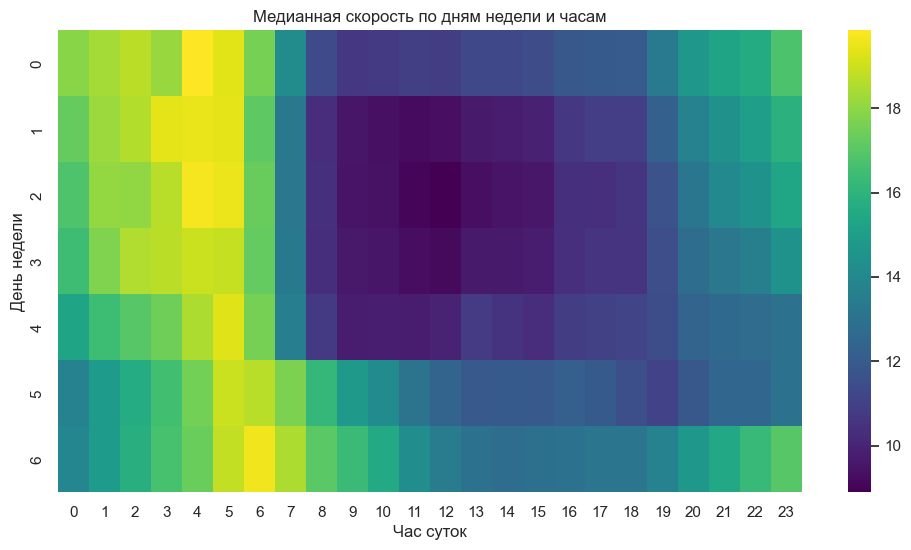

In [22]:
speed_pivot = reasonable_speed.pivot_table(values='speed', 
                                           index='dayofweek', 
                                           columns='hour', 
                                           aggfunc='median')

plt.figure(figsize=(12, 6))
sns.heatmap(speed_pivot, cmap='viridis')
plt.xlabel('Час суток')
plt.ylabel('День недели')
plt.title('Медианная скорость по дням недели и часам')
plt.show()

Не забудьте удалить колонку со значением скорости из данных!

**Вопрос**: Почему значение скорости нельзя использовать во время обучения?

In [23]:
df = df.drop('speed', axis=1)

**Вопрос**: Посмотрите внимательно на график и скажите, в какие моменты времени скорость минимальна; максимальна.

Создайте признаки "поездка совершается в период пробок" и "поездка совершается в период свободных дорог" (естественно, они не должен зависеть от скорости!):

In [24]:
df['is_rush_hour'] = ((df['dayofweek'] < 5) & 
                      ((df['hour'].isin([7, 8, 9, 17, 18, 19])))).astype(int)

df['is_free_road'] = ((df['hour'].isin([0, 1, 2, 3, 4, 5]) | 
                       (df['dayofweek'] >= 5))).astype(int)

**Задание 8 (0.25 балла)**. Как уже было замечено выше, на карте выделяются две точки вдали от Манхэттена. Для каждой из них добавьте в выборку два признака: началась ли поездка в ней и закончилась ли она в ней.

In [25]:
jfk_lat, jfk_lon = 40.6413, -73.7781
lga_lat, lga_lon = 40.7769, -73.8740

df['pickup_at_jfk'] = (np.abs(df['pickup_latitude'] - jfk_lat) < 0.01).astype(int)
df['pickup_at_lga'] = (np.abs(df['pickup_latitude'] - lga_lat) < 0.01).astype(int)
df['dropoff_at_jfk'] = (np.abs(df['dropoff_latitude'] - jfk_lat) < 0.01).astype(int)
df['dropoff_at_lga'] = (np.abs(df['dropoff_latitude'] - lga_lat) < 0.01).astype(int)

Для каждого из созданных признаков нарисуйте "ящик с усами" (`sns.boxplot`) распределения логарифма времени поездки

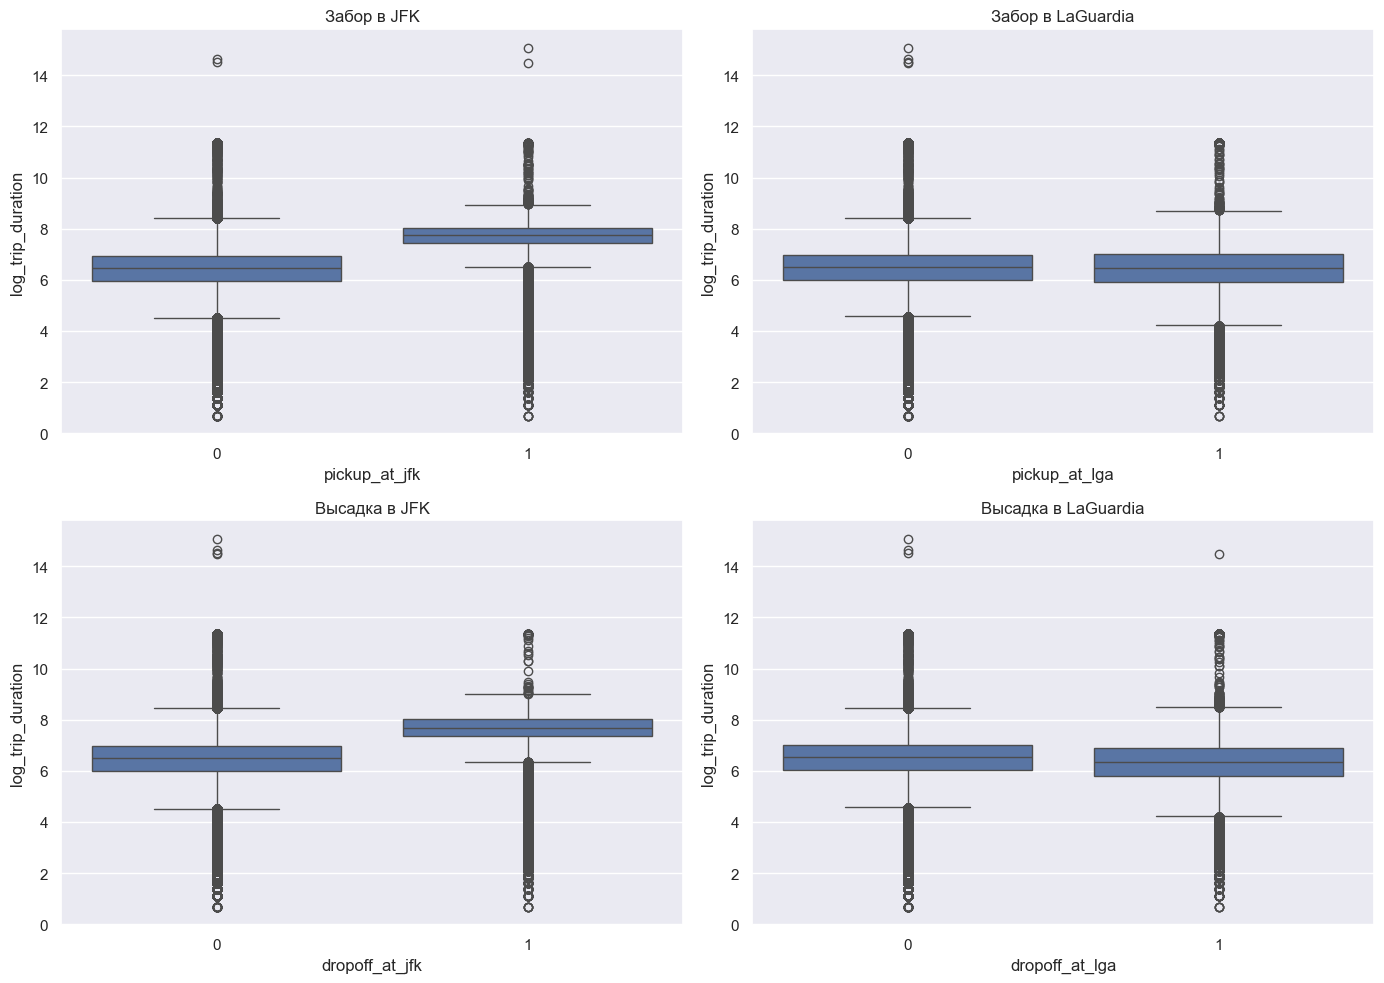

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='pickup_at_jfk', y='log_trip_duration', ax=axes[0, 0])
axes[0, 0].set_title('Забор в JFK')

sns.boxplot(data=df, x='pickup_at_lga', y='log_trip_duration', ax=axes[0, 1])
axes[0, 1].set_title('Забор в LaGuardia')

sns.boxplot(data=df, x='dropoff_at_jfk', y='log_trip_duration', ax=axes[1, 0])
axes[1, 0].set_title('Высадка в JFK')

sns.boxplot(data=df, x='dropoff_at_lga', y='log_trip_duration', ax=axes[1, 1])
axes[1, 1].set_title('Высадка в LaGuardia')

plt.tight_layout()
plt.show()

**Вопрос**: судя по графикам, как вы думаете, хорошими ли получились эти признаки?

<img src="https://www.dropbox.com/s/xson9nukz5hba7c/map.png?raw=1" align="right" width="20%" style="margin-left: 20px; margin-bottom: 20px">

**Задание 9 (1 балл)**. Сейчас мы почти что не используем сами значения координат. На это есть несколько причин: по отдельности рассматривать широту и долготу не имеет особого смысла, стоит рассматривать их вместе. Во-вторых, понятно, что зависимость между нашим таргетом и координатами не линейная. Чтобы как-то использовать координаты, можно прибегнуть к следующему трюку: обрамим область с наибольшим количеством поездок прямоугольником (как на рисунке). Разобьем этот прямоугольник на ячейки. Каждой точке сопоставим номер ее ячейки, а тем точкам, что не попали ни в одну из ячеек, сопоставим значение -1.

Напишите трансформер, который сначала разбивает показанную на рисунке область на ячейки, а затем создает два признака: номер ячейки, в которой началась поездка, и номер ячейки, в которой закончилась поездка. Количество строк и столбцов выберите самостоятельно.

Обратите внимание, что все вычисления должны быть векторизованными, трансформер не должен модифицировать передаваемую ему выборку inplace, а все необходимые статистики (если они вдруг нужны) нужно считать только по обучающей выборке в методе `fit`:

In [27]:
from sklearn.base import BaseEstimator, TransformerMixin

class MapGridTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_rows=10, n_cols=10, lat_range=(40.5, 41.0), lon_range=(-74.3, -73.7)):
        self.n_rows = n_rows
        self.n_cols = n_cols
        self.lat_range = lat_range
        self.lon_range = lon_range
        
    def fit(self, X, y=None):
        self.lat_bins = np.linspace(self.lat_range[0], self.lat_range[1], self.n_rows + 1)
        self.lon_bins = np.linspace(self.lon_range[0], self.lon_range[1], self.n_cols + 1)
        return self
    
    def transform(self, X):
        X = X.copy()
        
        pickup_lat_cell = np.digitize(X['pickup_latitude'], self.lat_bins) - 1
        pickup_lon_cell = np.digitize(X['pickup_longitude'], self.lon_bins) - 1
        X['pickup_cell'] = pickup_lat_cell * self.n_cols + pickup_lon_cell
        
        dropoff_lat_cell = np.digitize(X['dropoff_latitude'], self.lat_bins) - 1
        dropoff_lon_cell = np.digitize(X['dropoff_longitude'], self.lon_bins) - 1
        X['dropoff_cell'] = dropoff_lat_cell * self.n_cols + dropoff_lon_cell
        
        X.loc[(X['pickup_latitude'] < self.lat_range[0]) | 
              (X['pickup_latitude'] > self.lat_range[1]) |
              (X['pickup_longitude'] < self.lon_range[0]) | 
              (X['pickup_longitude'] > self.lon_range[1]), 'pickup_cell'] = -1
        
        X.loc[(X['dropoff_latitude'] < self.lat_range[0]) | 
              (X['dropoff_latitude'] > self.lat_range[1]) |
              (X['dropoff_longitude'] < self.lon_range[0]) | 
              (X['dropoff_longitude'] > self.lon_range[1]), 'dropoff_cell'] = -1
        
        return X
    
    def show_map(self):
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(10, 8))
        
        for i in range(len(self.lat_bins)):
            ax.axhline(y=self.lat_bins[i], color='r', linestyle='-', linewidth=0.5)
        for j in range(len(self.lon_bins)):
            ax.axvline(x=self.lon_bins[j], color='b', linestyle='-', linewidth=0.5)
        
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_title('Map Grid')
        plt.show()

**Задание 10 (0.25 балла)**. Обучите `Ridge`-регрессию со стандартными параметрами на признаках, которые мы выделили к текущему моменту. Категориальные признаки закодируйте через one-hot-кодирование, числовые признаки отмасштабируйте.

In [28]:
features = ['dayofweek', 'month', 'hour', 'dayofyear', 'is_new_year', 'is_anomaly2',
            'is_rush_hour', 'is_free_road', 'pickup_at_jfk', 'pickup_at_lga',
            'dropoff_at_jfk', 'dropoff_at_lga', 'log_haversine']

grid_transformer = MapGridTransformer(n_rows=10, n_cols=10)
df = grid_transformer.fit_transform(df)
features.extend(['pickup_cell', 'dropoff_cell'])

X = df[features]
y = df['log_trip_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

categorical_features = ['dayofweek', 'month', 'pickup_cell', 'dropoff_cell']
numerical_features = [f for f in features if f not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)

rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_test), np.expm1(y_pred)))
print(f"RMSLE Ridge регрессии: {rmsle:.4f}")

RMSLE Ridge регрессии: 0.4923


## Часть 3. Изучаем оставшиеся признаки (1 балл)

**Задание 11 (0.75 баллов)**. У нас осталось еще 3 признака, которые мы не исследовали: `vendor_id`, `passenger_count` и `store_and_fwd_flag`.

**Вопрос**: Подумайте, почему каждый из этих признаков может быть потенциально полезным.

Посчитайте, сколько есть уникальных значений у каждого из этих признаков:

In [29]:
print(df['vendor_id'].unique())
print(df['passenger_count'].unique())
print(df['store_and_fwd_flag'].unique())

[2 1]
[1 6 4 2 3 5 0 7 9 8]
['N' 'Y']


Постройте "ящики с усами" распределений логарифма времени поездки в зависимости от значений каждого из признаков

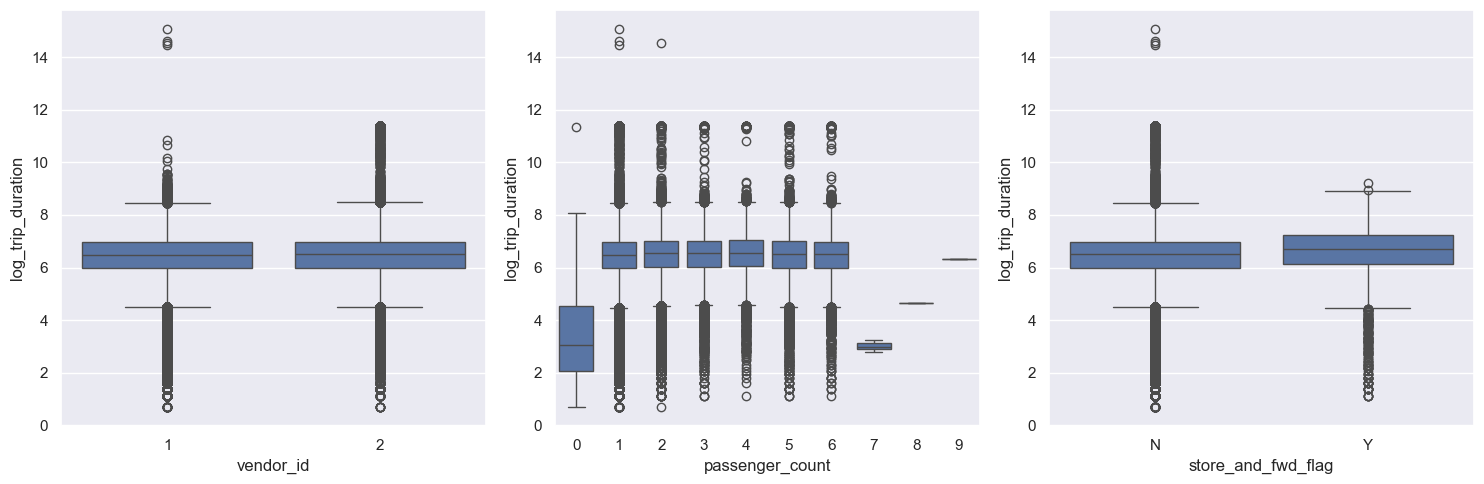

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x='vendor_id', y='log_trip_duration', data=df, ax=axes[0])
sns.boxplot(x='passenger_count', y='log_trip_duration', data=df, ax=axes[1])
sns.boxplot(x='store_and_fwd_flag', y='log_trip_duration', data=df, ax=axes[2])
plt.tight_layout()
plt.show()

Переведите признаки `vendor_id` и `store_and_fwd_flag` в значения $\{0;1\}$

In [31]:
df['vendor_id'] = df['vendor_id'] - 1 
df['store_and_fwd_flag'] = (df['store_and_fwd_flag'] == 'Y').astype(int)

**Вопрос**: Основываясь на графиках выше, как вы думаете, будут ли эти признаки сильными?

**Задание 12 (0.25 баллов)**. Проверьте свои предположения, обучив модель в том числе и на этих трех признаках. Обучайте `Ridge`-регрессию со стандартными параметрами. Категориальные признаки закодируйте one-hot-кодированием, а численные отмасштабируйте.

In [32]:
features.extend(['vendor_id', 'passenger_count', 'store_and_fwd_flag'])

X = df[features]
y = df['log_trip_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

categorical_features = ['dayofweek', 'month', 'pickup_cell', 'dropoff_cell']
numerical_features = [f for f in features if f not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)

rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_test), np.expm1(y_pred)))
print(f"RMSLE Ridge регрессии со всеми признаками: {rmsle:.4f}")

RMSLE Ridge регрессии со всеми признаками: 0.4921


Если признаки не дали какого-то ощутимого улучшения метрики, их можно выбросить из данных.

## Часть 4. Улучшаем модель (3 балла)

**Задание 13 (1 балл)**. В наших данных есть нетипичные объекты: с аномально маленьким времени поездки, с очень большим пройденным расстоянием или очень большими остатками регрессии. В этом задании предлагается исключить такие объекты из обучающей выборки. Для этого нарисуйте гистограммы распределения упомянутых выше величин, выберите объекты, которые можно назвать выбросами, и очистите обучающую выборку от них.

Отметим, что хотя эти объекты и выглядят как выбросы, в тестовой выборке тоже скорее всего будут объекты с такими же странными значениями целевой переменной и/или признаков. Поэтому, возможно, чистка обучающей выборки приведёт к ухудшению качества на тесте. Тем не менее, всё равно лучше удалять выбросы из обучения, чтобы модель получалась более разумной и интерпретируемой.

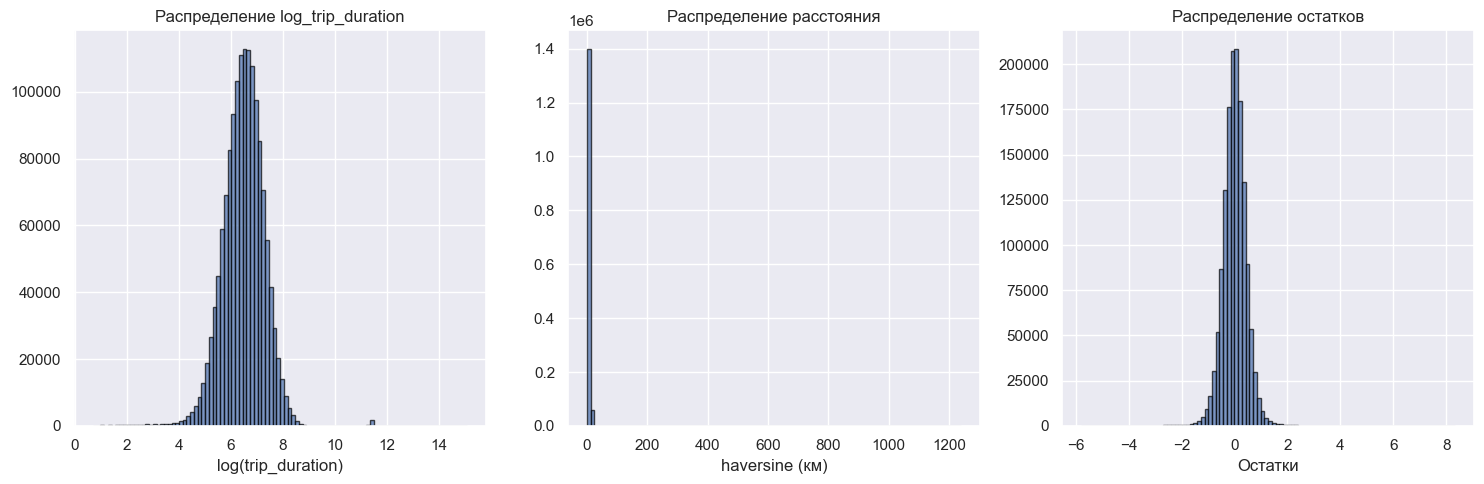

Размер исходной выборки: 1458644
Размер очищенной выборки: 1407281


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['log_trip_duration'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('log(trip_duration)')
axes[0].set_title('Распределение log_trip_duration')

axes[1].hist(df['haversine'], bins=100, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('haversine (км)')
axes[1].set_title('Распределение расстояния')

y_pred_all = ridge_pipeline.predict(X)
residuals = y - y_pred_all
axes[2].hist(residuals, bins=100, edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Остатки')
axes[2].set_title('Распределение остатков')

plt.tight_layout()
plt.show()

df_clean = df[(df['log_trip_duration'] < df['log_trip_duration'].quantile(0.99)) &
              (df['haversine'] < df['haversine'].quantile(0.99)) &
              (residuals < residuals.quantile(0.99)) &
              (residuals > residuals.quantile(0.01))]

print(f"Размер исходной выборки: {len(df)}")
print(f"Размер очищенной выборки: {len(df_clean)}")

Сейчас у нас очень много категориальных признаков. В категориальных признаках могут содержаться редкие категории, обычно это плохо: модель сильно переобучается на таких примерах. Попробуйте объединить редкие категории в одну. Естественно, делать это нужно только для действительно редких категорий.

In [ ]:
passenger_counts = df_clean['passenger_count'].value_counts()
rare_passengers = passenger_counts[passenger_counts < len(df_clean) * 0.01].index
df_clean.loc[:, 'passenger_count'] = df_clean['passenger_count'].apply(
    lambda x: 9 if x in rare_passengers else x
)

C:\Users\Kirill\AppData\Local\Temp\ipykernel_24340\2720159448.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['passenger_count'] = df_clean['passenger_count'].apply(


Обучите модель на очищенных данных и посчитайте качество на тестовой выборке.

**Задание 14 (1 балл)**. После OneHot-кодирования количество признаков в нашем датасете сильно возрастает. Посчитайте колиество признаков до и после кодирования категориальных признаков.

In [35]:
X_clean = df_clean[features]
y_clean = df_clean['log_trip_duration']

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.3, random_state=42)

categorical_features = ['dayofweek', 'month', 'pickup_cell', 'dropoff_cell']
numerical_features = [f for f in features if f not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)

rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_test), np.expm1(y_pred)))
print(f"RMSLE на очищенных данных: {rmsle:.4f}")

RMSLE на очищенных данных: 0.3919


Попробуйте обучить не `Ridge`-, а `Lasso`-регрессию. Какой метод лучше?

In [36]:
print(f"Количество признаков до кодирования: {len(features)}")

preprocessor_fitted = preprocessor.fit(X_train)

num_features = len(numerical_features)
cat_encoder = preprocessor_fitted.named_transformers_['cat']
cat_features = len(cat_encoder.get_feature_names_out(categorical_features))

print(f"Количество численных признаков: {num_features}")
print(f"Количество категориальных признаков после кодирования: {cat_features}")
print(f"Общее количество признаков после кодирования: {num_features + cat_features}")

Количество признаков до кодирования: 18
Количество численных признаков: 14
Количество категориальных признаков после кодирования: 164
Общее количество признаков после кодирования: 178


Разбейте обучающую выборку на обучающую и валидационную в отношении 8:2. По валидационной выборке подберите оптимальные значения параметра регуляризации (по логарифмической сетке) для `Ridge` и `Lasso`, на тестовой выборке измерьте качество лучшей полученной модели.

In [37]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)

rmsle_lasso = np.sqrt(mean_squared_log_error(np.expm1(y_test), np.expm1(y_pred_lasso)))
print(f"RMSLE Lasso регрессии: {rmsle_lasso:.4f}")
print(f"RMSLE Ridge регрессии: {rmsle:.4f}")

RMSLE Lasso регрессии: 0.6960
RMSLE Ridge регрессии: 0.3919


Для каждого перебранного `alpha` для Lasso посчитайте количество нулевых весов в модели и нарисуйте график зависимости его от `alpha`. Как сильно придётся потерять в качестве, если мы хотим с помощью Lasso избавиться хотя бы от половины признаков?

In [ ]:
from sklearn.model_selection import GridSearchCV

X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

ridge_params = {'regressor__alpha': np.logspace(-2, 2, 10)}
ridge_grid = GridSearchCV(ridge_pipeline, ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train_sub, y_train_sub)

print("Лучшие параметры для Ridge:", ridge_grid.best_params_)
print("Лучший score для Ridge:", np.sqrt(-ridge_grid.best_score_))

lasso_params = {'regressor__alpha': np.logspace(-4, 0, 10)}
lasso_grid = GridSearchCV(lasso_pipeline, lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train_sub, y_train_sub)

print("Лучшие параметры для Lasso:", lasso_grid.best_params_)
print("Лучший score для Lasso:", np.sqrt(-lasso_grid.best_score_))

best_ridge = ridge_grid.best_estimator_
y_pred_best = best_ridge.predict(X_test)
rmsle_best = np.sqrt(mean_squared_log_error(np.expm1(y_test), np.expm1(y_pred_best)))
print(f"Лучший RMSLE на тесте: {rmsle_best:.4f}")

Лучшие параметры для Ridge: {'regressor__alpha': np.float64(0.027825594022071243)}
Лучший score для Ridge: 0.39281604222969885
Лучшие параметры для Lasso: {'regressor__alpha': np.float64(0.0001)}
Лучший score для Lasso: 0.39382760409909373
Лучший RMSLE на тесте: 0.3919


<img src="https://www.dropbox.com/s/wp4jj0599np17lh/map_direction.png?raw=1" width="20%" align="right" style="margin-left: 20px">

**Задание 15 (1 балл)**. Часто бывает полезным использовать взаимодействия признаков (feature interactions), то есть строить новые признаки на основе уже существующих. Выше мы разбили карту Манхэттена на ячейки и придумали признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка".

Давайте попробуем сделать следующее: посчитаем, сколько раз встречается каждая возможная пара этих признаков в нашем датасете и выберем 100 самых частых пар. Закодируем поездки с этими частыми парами как категориальный признак, остальным объектам припишем -1. Получается, что мы закодировали, откуда и куда должно было ехать такси.

Также можете придумать ещё какой-нибудь способ сделать признаки про маршрут. Если эти признаки будут давать хороший прирост в качестве, то за это могут быть даны дополнительные бонусные баллы.

**Вопрос**: Почему такой признак потенциально полезный? Почему линейная модель не может самостоятельно "вытащить" эту информацию, ведь у нее в распоряжении есть признаки "из какой ячейки началась поездка" и "в какой ячейке закончилась поездка"?

In [ ]:
alphas = np.logspace(-4, 0, 50)
zero_coefs = []
scores = []

for alpha in alphas:
    lasso = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', Lasso(alpha=alpha, max_iter=10000))
    ])
    lasso.fit(X_train_sub, y_train_sub)
    
    coefs = lasso.named_steps['regressor'].coef_
    zero_coefs.append(np.sum(coefs == 0))
    
    y_pred_val = lasso.predict(X_val)
    score = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(y_pred_val)))
    scores.append(score)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(alphas, zero_coefs)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Количество нулевых весов')
plt.title('Зависимость количества нулевых весов от alpha')

plt.subplot(1, 2, 2)
plt.plot(alphas, scores)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('RMSLE')
plt.title('Зависимость RMSLE от alpha')

plt.tight_layout()
plt.show()

half_features = len(features) // 2
alpha_half = alphas[np.argmin(np.abs(np.array(zero_coefs) - half_features))]
score_half = scores[np.argmin(np.abs(np.array(zero_coefs) - half_features))]
print(f"Alpha для обнуления половины признаков: {alpha_half:.4f}")
print(f"Потеря в качестве: {score_half - min(scores):.4f}")

Заново обучите модель (`Ridge`, если она дала более высокое качество в предыдущих экспериментах, и `Lasso` иначе) на новых даннных и посчитайте качество на тестовой выборке

In [ ]:
route_counts = df_clean.groupby(['pickup_cell', 'dropoff_cell']).size().reset_index(name='count')
top_100_routes = route_counts.nlargest(100, 'count')[['pickup_cell', 'dropoff_cell']]

df_clean['route'] = -1
for idx, row in top_100_routes.iterrows():
    mask = (df_clean['pickup_cell'] == row['pickup_cell']) & \
           (df_clean['dropoff_cell'] == row['dropoff_cell'])
    df_clean.loc[mask, 'route'] = idx

print(f"Создан признак route с {df_clean['route'].nunique()} уникальными значениями")

**Задание 16 (бонус, 1 балл)**. Где, как не для нашей задачи, считать манхэттенское расстояние?

**Вопрос**: Найдите, что такое манхэттенское расстояние и почему оно так называется. Как оно нам может помочь?

Введите систему координат на нашей карте так, чтобы оси были параллельны улицам Манхэттена, и добавьте сначала в данные признак "манхэттенское расстояние между пунктом отправления и пунктом назначения", а затем и логарифм этого признака. Посчитайте корреляцию между вашим новыми признаком и таргетом; между `log_haversine` и таргетом. В каком случае корреляция больше?

Нарисуйте карту, где покажете выбранные оси. Чтобы мы могли проверить вашу работу, просьба сделать скрин этой карты и приложить картинку (если мы откроем ваш ноутбук, виджеты отображаться не будут). 

In [ ]:
features_with_route = features + ['route']

X = df_clean[features_with_route]
y = df_clean['log_trip_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

categorical_features = ['dayofweek', 'month', 'pickup_cell', 'dropoff_cell', 'route']
numerical_features = [f for f in features_with_route if f not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)

rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_test), np.expm1(y_pred)))
print(f"RMSLE с признаком маршрута: {rmsle:.4f}")

Заново обучите модель на новых даннных и посчитайте качество на тестовой выборке. Стало ли лучше? Объясните полученный результат.

In [ ]:
def manhattan_distance(lat1, lon1, lat2, lon2):
    # 1 градус широты ≈ 111 км
    # 1 градус долготы ≈ 111 * cos(lat) км
    lat = np.radians((lat1 + lat2) / 2)
    dlat = np.abs(lat2 - lat1) * 111
    dlon = np.abs(lon2 - lon1) * 111 * np.cos(lat)
    return dlat + dlon

df_clean['manhattan_distance'] = manhattan_distance(
    df_clean['pickup_latitude'], df_clean['pickup_longitude'],
    df_clean['dropoff_latitude'], df_clean['dropoff_longitude']
)

df_clean['log_manhattan_distance'] = np.log1p(df_clean['manhattan_distance'])

print(f"Корреляция manhattan_distance с log_trip_duration: {df_clean['manhattan_distance'].corr(df_clean['log_trip_duration']):.4f}")
print(f"Корреляция log_manhattan_distance с log_trip_duration: {df_clean['log_manhattan_distance'].corr(df_clean['log_trip_duration']):.4f}")
print(f"Корреляция log_haversine с log_trip_duration: {df_clean['log_haversine'].corr(df_clean['log_trip_duration']):.4f}")

**Задание 17 (бонус, 2 балла)**. Реализуйте трансформер, который строит разбиение карты по шестигранной решётке с помощью библиотеки [H3](https://github.com/uber/h3-py) и вычисляет признаки на основе такого разбиения.

Признаки могут быть самые разные: расстояние между точкой старта и финиша, посчитанное в количестве шестиугольников; статистика по числу поездок и по их продолжительности в соседних шестиугольниках.

Важно: производительность библиотеки существенно зависит от количества шестиугольников на карте (определяется параметром resolution). Подберите такое разрешение, при котором ваш код будет работать за приемлемое время.

При построении признаков старайтесь не допустить утечки целевой переменной (подробнее про это можно почитать в материалах 1-го семинара) — в противном случае хорошего качества на тестовой выборке достичь не получится.

Измерьте качество после добавления новых признаков. За улучшение функционала ошибки на каждые 0.005 на тестовой выборке будет даваться 0.5 бонусных балла. Можно получить до 2 бонусных баллов за это задание.

In [ ]:
features_manhattan = features_with_route + ['log_manhattan_distance']

X = df_clean[features_manhattan]
y = df_clean['log_trip_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

categorical_features = ['dayofweek', 'month', 'pickup_cell', 'dropoff_cell', 'route']
numerical_features = [f for f in features_manhattan if f not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)

rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_test), np.expm1(y_pred)))
print(f"RMSLE с манхэттенским расстоянием: {rmsle:.4f}")